# Byzantine-FL Demo on `transaction_data.csv`

This notebook adapts the Byzantine FL setup to a transaction dataset and produces a demo-friendly experiment with visualizations.

## What this notebook does
- Loads and preprocesses `transaction_data.csv`.
- Builds a simple federated binary classification task.
- Simulates Byzantine clients using ByzFL attacks.
- Compares non-robust and robust aggregation strategies.
- Visualizes data characteristics and training outcomes.


In [1]:
import os
import sys
import random
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Add local ByzFL source path.
repo_root = os.path.abspath("..")
byzfl_src = os.path.join(os.getcwd(), "byzfl")
if byzfl_src not in sys.path:
    sys.path.insert(0, byzfl_src)

import byzfl

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")
device = torch.device("cpu")
device


device(type='cpu')

In [2]:
# Load and lightly sample for a quick demo runtime.
data_path = os.path.join(repo_root, "transaction_data.csv")
df = pd.read_csv(data_path)
if len(df) > 50000:
    df = df.sample(50000, random_state=SEED).reset_index(drop=True)

# Binary target: 1 if anonymous user id (-1), else 0.
df["is_anonymous"] = (df["UserId"].astype(str) == "-1").astype(int)

# Parse and derive compact time features.
df["TransactionTime"] = pd.to_datetime(df["TransactionTime"], errors="coerce", utc=False)
df = df.dropna(subset=["TransactionTime", "NumberOfItemsPurchased", "CostPerItem", "Country"]).copy()
df["hour"] = df["TransactionTime"].dt.hour
df["day_of_week"] = df["TransactionTime"].dt.dayofweek
df["total_spend"] = pd.to_numeric(df["NumberOfItemsPurchased"], errors="coerce") * pd.to_numeric(df["CostPerItem"], errors="coerce")

num_cols = ["NumberOfItemsPurchased", "CostPerItem", "total_spend", "hour", "day_of_week"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=num_cols).copy()

# One-hot encode top countries to keep dimensionality manageable.
top_countries = df["Country"].value_counts().head(10).index
df["CountryCompact"] = np.where(df["Country"].isin(top_countries), df["Country"], "Other")
country_dummies = pd.get_dummies(df["CountryCompact"], prefix="country")

X_df = pd.concat([df[num_cols], country_dummies], axis=1)
y = df["is_anonymous"].values.astype(np.int64)

# Standardize numeric columns.
X_df[num_cols] = (X_df[num_cols] - X_df[num_cols].mean()) / (X_df[num_cols].std() + 1e-6)
X = X_df.values.astype(np.float32)

print(f"Rows used: {len(X):,}")
print(f"Feature dim: {X.shape[1]}")
print(f"Positive rate (anonymous): {y.mean():.4f}")


Rows used: 50,000
Feature dim: 16
Positive rate (anonymous): 0.2461


/tmp/ipykernel_27222/1457566581.py:11: FutureWarning: Parsed string "Sun Apr 29 13:51:00 IST 2018" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df["TransactionTime"] = pd.to_datetime(df["TransactionTime"], errors="coerce", utc=False)


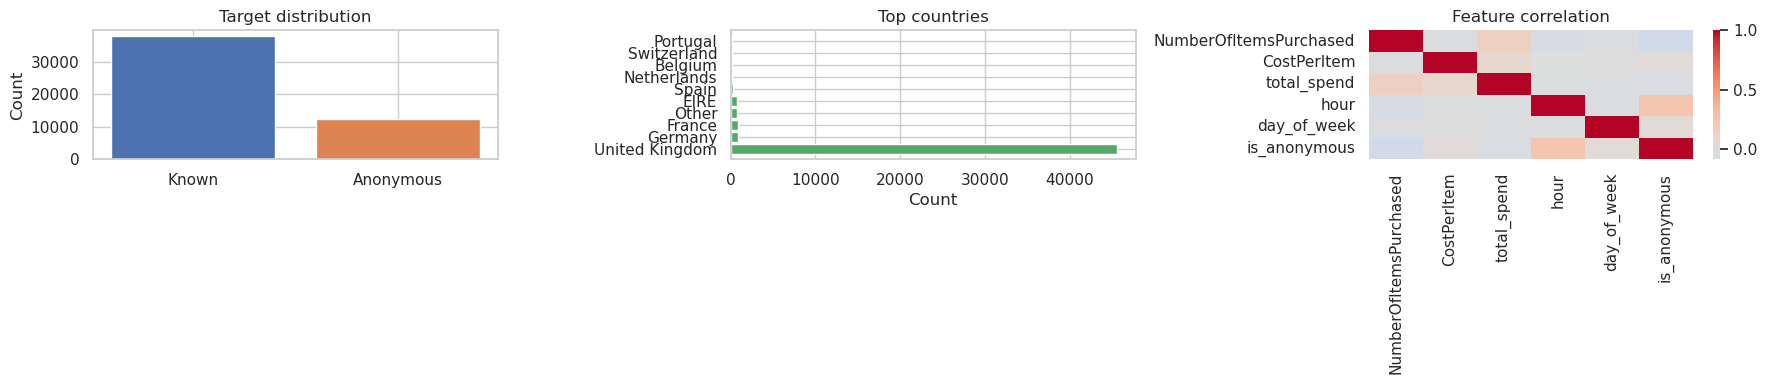

In [3]:
# Quick EDA visuals.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

class_counts = pd.Series(y).value_counts().sort_index()
axes[0].bar(["Known", "Anonymous"], class_counts.values, color=["#4c72b0", "#dd8452"])
axes[0].set_title("Target distribution")
axes[0].set_ylabel("Count")

country_plot = df["CountryCompact"].value_counts().head(10)
axes[1].barh(country_plot.index, country_plot.values, color="#55a868")
axes[1].set_title("Top countries")
axes[1].set_xlabel("Count")

corr = df[num_cols + ["is_anonymous"]].corr(numeric_only=True)
sns.heatmap(corr, ax=axes[2], cmap="coolwarm", center=0)
axes[2].set_title("Feature correlation")

plt.tight_layout()
plt.show()


In [4]:
# Train/test split and federated client partitioning.
n = len(X)
idx = np.arange(n)
np.random.shuffle(idx)
split = int(0.8 * n)
train_idx, test_idx = idx[:split], idx[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=1024,
    shuffle=False,
)

def make_client_loaders(X_in, y_in, n_clients=8, batch_size=256, non_iid=True):
    if non_iid:
        order = np.argsort(y_in)
        X_in = X_in[order]
        y_in = y_in[order]
    shards_X = np.array_split(X_in, n_clients)
    shards_y = np.array_split(y_in, n_clients)
    loaders = []
    for Xi, yi in zip(shards_X, shards_y):
        ds = TensorDataset(torch.tensor(Xi), torch.tensor(yi))
        loaders.append(DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True))
    return loaders

client_loaders = make_client_loaders(X_train, y_train, n_clients=8, batch_size=256, non_iid=True)
len(client_loaders)


8

In [5]:
class LogisticHead(nn.Module):
    def __init__(self, in_dim, out_dim=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return self.fc(x)

def flatten_grads(model):
    parts = []
    shapes = []
    for p in model.parameters():
        g = p.grad.detach().clone().view(-1)
        parts.append(g)
        shapes.append(p.shape)
    return torch.cat(parts), shapes

def set_model_grad_from_flat(model, flat_grad):
    start = 0
    for p in model.parameters():
        num = p.numel()
        p.grad = flat_grad[start:start+num].view_as(p).clone()
        start += num

def evaluate(model, loader, return_predictions=False):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    criterion = nn.CrossEntropyLoss()
    all_y_true, all_y_pred = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            pred = logits.argmax(dim=1)
            total += yb.numel()
            correct += (pred == yb).sum().item()
            loss_sum += loss.item() * yb.numel()
            if return_predictions:
                all_y_true.append(yb.cpu().numpy())
                all_y_pred.append(pred.cpu().numpy())

    avg_loss = loss_sum / total
    avg_acc = correct / total

    if return_predictions:
        return avg_loss, avg_acc, np.concatenate(all_y_true), np.concatenate(all_y_pred)
    return avg_loss, avg_acc


In [6]:
@dataclass
class ExperimentConfig:
    name: str
    attack_name: str
    aggregator_name: str
    aggregator: object
    attack: Optional[object]
    f_byz: int

def run_federated_experiment(config, rounds=80, lr=0.25):
    model = LogisticHead(X_train.shape[1]).to(device)
    criterion = nn.CrossEntropyLoss()

    # Per-client iterators.
    client_iters = [iter(dl) for dl in client_loaders]

    history = {
        "round": [],
        "test_loss": [],
        "test_acc": [],
        "agg_update_norm": [],
    }

    for rnd in range(rounds):
        honest_grads = []

        # Honest client local gradients.
        for i, dl in enumerate(client_loaders):
            try:
                xb, yb = next(client_iters[i])
            except StopIteration:
                client_iters[i] = iter(dl)
                xb, yb = next(client_iters[i])

            xb, yb = xb.to(device), yb.to(device)
            model.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            flat_grad, _ = flatten_grads(model)
            honest_grads.append(flat_grad)

        honest_stack = torch.stack(honest_grads)

        # Byzantine vectors crafted from honest gradients.
        if config.f_byz > 0 and config.attack is not None:
            byz_vec = config.attack(honest_stack)
            byz_stack = byz_vec.unsqueeze(0).repeat(config.f_byz, 1)
            all_vectors = torch.cat([honest_stack, byz_stack], dim=0)
        else:
            all_vectors = honest_stack

        agg_grad = config.aggregator(all_vectors)

        # One global optimizer step with the aggregated gradient.
        model.zero_grad()
        set_model_grad_from_flat(model, agg_grad)
        with torch.no_grad():
            for p in model.parameters():
                p -= lr * p.grad

        test_loss, test_acc = evaluate(model, test_loader)
        history["round"].append(rnd)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["agg_update_norm"].append(torch.norm(agg_grad).item())

    metrics_loss, metrics_acc, y_true_eval, y_pred_eval = evaluate(model, test_loader, return_predictions=True)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_eval,
        y_pred_eval,
        average="binary",
        zero_division=0,
    )
    cm = confusion_matrix(y_true_eval, y_pred_eval)

    metrics = {
        "experiment": config.name,
        "attack": config.attack_name,
        "aggregator": config.aggregator_name,
        "test_loss": metrics_loss,
        "test_acc": metrics_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }

    return pd.DataFrame(history), metrics


TypeError: unsupported operand type(s) for |: 'type' and 'NoneType'

In [7]:
# Configure experiments.
f_byz = 2
ipm_attack = byzfl.InnerProductManipulation(tau=3.0)
alie_attack = byzfl.ALittleIsEnough(tau=1.5)

experiments = [
    ExperimentConfig(
        name="No attack + Average",
        attack_name="None",
        aggregator_name="Average",
        aggregator=byzfl.Average(),
        attack=None,
        f_byz=0,
    ),
    # IPM attack experiments
    ExperimentConfig(
        name="IPM + Average",
        attack_name="IPM",
        aggregator_name="Average",
        aggregator=byzfl.Average(),
        attack=ipm_attack,
        f_byz=f_byz,
    ),
    ExperimentConfig(
        name="IPM + Median",
        attack_name="IPM",
        aggregator_name="Median",
        aggregator=byzfl.Median(),
        attack=ipm_attack,
        f_byz=f_byz,
    ),
    ExperimentConfig(
        name="IPM + TrMean",
        attack_name="IPM",
        aggregator_name="TrMean",
        aggregator=byzfl.TrMean(f=f_byz),
        attack=ipm_attack,
        f_byz=f_byz,
    ),
    # ALIE attack experiments
    ExperimentConfig(
        name="ALIE + Average",
        attack_name="ALIE",
        aggregator_name="Average",
        aggregator=byzfl.Average(),
        attack=alie_attack,
        f_byz=f_byz,
    ),
    ExperimentConfig(
        name="ALIE + Median",
        attack_name="ALIE",
        aggregator_name="Median",
        aggregator=byzfl.Median(),
        attack=alie_attack,
        f_byz=f_byz,
    ),
    ExperimentConfig(
        name="ALIE + TrMean",
        attack_name="ALIE",
        aggregator_name="TrMean",
        aggregator=byzfl.TrMean(f=f_byz),
        attack=alie_attack,
        f_byz=f_byz,
    ),
]

all_histories = []
all_metrics = []
for cfg in experiments:
    print(f"Running: {cfg.name}")
    hist, metrics = run_federated_experiment(cfg, rounds=80, lr=0.25)
    hist["experiment"] = cfg.name
    hist["attack"] = cfg.attack_name
    hist["aggregator"] = cfg.aggregator_name
    all_histories.append(hist)
    all_metrics.append(metrics)

results_df = pd.concat(all_histories, ignore_index=True)
metrics_df = pd.DataFrame(all_metrics)
results_df.head()


NameError: name 'ExperimentConfig' is not defined

In [ ]:
# Accuracy trajectories (side-by-side by attack type).
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
attack_panels = ["None", "IPM", "ALIE"]

for ax, attack_name in zip(axes, attack_panels):
    sub_attack = results_df[results_df["attack"] == attack_name]
    for exp_name, sub in sub_attack.groupby("experiment"):
        ax.plot(sub["round"], sub["test_acc"], label=exp_name)
    ax.set_title(f"Attack: {attack_name}")
    ax.set_xlabel("Round")
    if attack_name == "None":
        ax.set_ylabel("Test accuracy")
    ax.legend(fontsize=8)

plt.suptitle("Byzantine FL accuracy by attack scenario", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Test loss trajectories.
plt.figure(figsize=(10, 5))
for name, sub in results_df.groupby("experiment"):
    plt.plot(sub["round"], sub["test_loss"], label=name)
plt.xlabel("Round")
plt.ylabel("Test loss")
plt.title("Byzantine FL: loss over rounds")
plt.legend()
plt.show()


In [ ]:
# Precision / Recall / F1 summary.
metrics_view = metrics_df[["experiment", "attack", "aggregator", "test_acc", "precision", "recall", "f1", "test_loss"]].sort_values(
    ["attack", "f1"], ascending=[True, False]
)
display(metrics_view)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, metric_name in zip(axes, ["precision", "recall", "f1"]):
    sns.barplot(
        data=metrics_df,
        x=metric_name,
        y="experiment",
        hue="attack",
        ax=ax,
        orient="h",
    )
    ax.set_xlim(0, 1)
    ax.set_title(metric_name.capitalize())
    ax.set_ylabel("")
    if metric_name != "f1":
        ax.legend_.remove()

axes[-1].legend(title="Attack", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Per-strategy classification metrics", y=1.02)
plt.tight_layout()
plt.show()


# Confusion matrices per strategy.

non_clean = metrics_df[metrics_df["attack"] != "None"].reset_index(drop=True)
num = len(non_clean)
cols = 3
rows = int(np.ceil(num / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, (_, row) in enumerate(non_clean.iterrows()):
    cm = row["confusion_matrix"]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i],
    )
    axes[i].set_title(f"{row['experiment']}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Confusion matrices (attack scenarios)", y=1.02)
plt.tight_layout()
plt.show()


## Interpretation notes

- Compare `IPM` vs `ALIE` rows to see which attack degrades each aggregator more.
- Compare `Average` against `Median` / `TrMean` within each attack to show robustness gains.
- Use `f_byz`, `tau`, and `rounds` to tune severity and produce stronger demo separation.
